# Finetuning a pretrained ViT to Oxford Flowers 102

To continue learning how to utilise ViTs and how attention works, I will be making a finetuned version of Oxford Flowers 102 following the same as the original paper.

In [12]:
import torch
import torch.nn as nn
from torch import Tensor

from torch.utils.data import DataLoader

import torchvision
from torchvision.datasets import Flowers102
from torchvision import transforms
import timm

import torchinfo

import matplotlib
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from typing import Dict, Optional


print(f"Torch version : {torch.__version__}")
print(f"Torchvision version : {torchvision.__version__}")
print(f"Torchinfo version : {torchinfo.__version__}")
print(f"Matplotlib version : {matplotlib.__version__}")



Torch version : 2.12.0
Torchvision version : 0.27.0
Torchinfo version : 1.8.0
Matplotlib version : 3.10.9


### Loading pretrained ViT

In [7]:
transform = transforms.Compose([
    transforms.Resize(384),
    transforms.CenterCrop(384),
    transforms.ToTensor()
])



train_data = Flowers102(
    root = "archive/flowers102",
    split="train",
    transform=transform,
    target_transform=None,
    download=True,
)

val_data = Flowers102(
    root = "archive/flowers102",
    split="val",
    transform=transform,
    target_transform=None,
    download=True,
)

test_data = Flowers102(
    root = "archive/flowers102",
    split="test",
    transform=transform,
    target_transform=None,
    download=True,
)

In [8]:
# Create class name to index mapping and vice versa
class_names = train_data.classes
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

In [9]:
if torch.torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

device

device(type='mps')

In [10]:
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    img_size=384,
    num_classes=102,
)

model = model.to(device)

## Creating functions to create a full training pipeline to finetune the model

In [11]:
def save_checkpoint(
    path: str,
    model: nn.Module,
    optimiser: torch.optim.Optimizer,
    scheduler: Optional[torch.optim.lr_scheduler._LRScheduler],
    step: int,
    best_acc: float,
) -> None:
    torch.save({
        "model": model.state_dict(),
        "optimiser": optimiser.state_dict(),
        "scheduler": scheduler.state_dict() if scheduler else None,
        "step": step,
        "best_acc": best_acc,
    }, path)

In [ ]:
def load_checkpoint(path: str, model: nn.Module) -> Dict:
    ckpt = torch.load(path, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    return ckpt

In [ ]:
@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device
) -> float:

    model.eval()

    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        logits = model(x)
        preds = logits.argmax(1)

        correct += (preds == y).sum().item()
        total += y.size(0)

    model.train()
    return correct / total

In [ ]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    device: torch.device,
    total_steps: int = 500,
    lr: float = 3e-3,
    eval_every: int = 100,
) -> None:

    model.to(device)

    optimiser = torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser,
        T_max=total_steps
    )

    loss_fn = nn.CrossEntropyLoss()

    best_acc = 0.0
    step = 0

    train_iter = iter(train_loader)

    model.train()

    while step < total_steps:

        # restart dataloader when exhausted
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)

        x, y = x.to(device), y.to(device)

        optimiser.zero_grad()

        logits: Tensor = model(x)
        loss: Tensor = loss_fn(logits, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimiser.step()
        scheduler.step()

        step += 1

        if step % eval_every == 0 or step == total_steps:

            val_acc = evaluate(model, val_loader, device)

            print(f"Step {step}/{total_steps} | val_acc={val_acc:.4f}")

            # save last checkpoint
            save_checkpoint(
                "finetuning_models/last_checkpoint.pth",
                model, optimiser, scheduler,
                step, best_acc
            )

            # save best model
            if val_acc > best_acc:
                best_acc = val_acc
                save_checkpoint(
                    "finetuning_models/best_model.pth",
                    model, optimiser, scheduler,
                    step, best_acc
                )


    load_checkpoint("finetuning_models/best_model.pth", model)
    test_acc = evaluate(model, test_loader, device)

    print(f"\nFINAL TEST ACC: {test_acc:.4f}")

## Proper training loop here

In [ ]:
num_workers = 0
BATCH_SIZE = 4096

train_dataloader = DataLoader(
  train_data,
  batch_size=BATCH_SIZE,
  shuffle=True,
  num_workers=num_workers,
  pin_memory=True,
  )

val_dataloader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)

test_dataloader = DataLoader(
  test_data,
  batch_size=BATCH_SIZE,
  shuffle=False,
  num_workers=num_workers,
  pin_memory=True,
)

In [ ]:
train_model(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    test_loader=test_dataloader,
    device=device,
    total_steps = 500,
    lr=3e-3,
)

I will train this on Google Colab and I'll show off how good the model is

In [ ]:
best_model = torch.load(
    "finetuning_models/best_model.pth",
    map_location="cpu"
)

model.load_state_dict(best_model["model"])
model.eval()

<All keys matched successfully>

### Creating a confusion matrix

There will be no clear details however it will be clear to see the diagonal if the model is accurate

In [ ]:
num_classes = len(class_names)

cm = torch.zeros(num_classes, num_classes,
                 dtype=torch.int64,
                 device=device)

model.eval()

with torch.no_grad():
    for x, y in test_dataloader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        preds = model(x).argmax(dim=1)

        cm.index_put_(
            (y, preds),
            torch.ones_like(y, dtype=torch.int64),
            accumulate=True
        )

cm = cm.cpu().numpy()
fig, ax = plt.subplots(figsize=(20, 20))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True,
    im_kw={"vmin": 0, "vmax": cm.max()}
)

ax.set_title("Confusion Matrix (102 classes)", fontsize=16)
plt.tight_layout()
plt.show()

I ran this all in Google colab and pasted the result

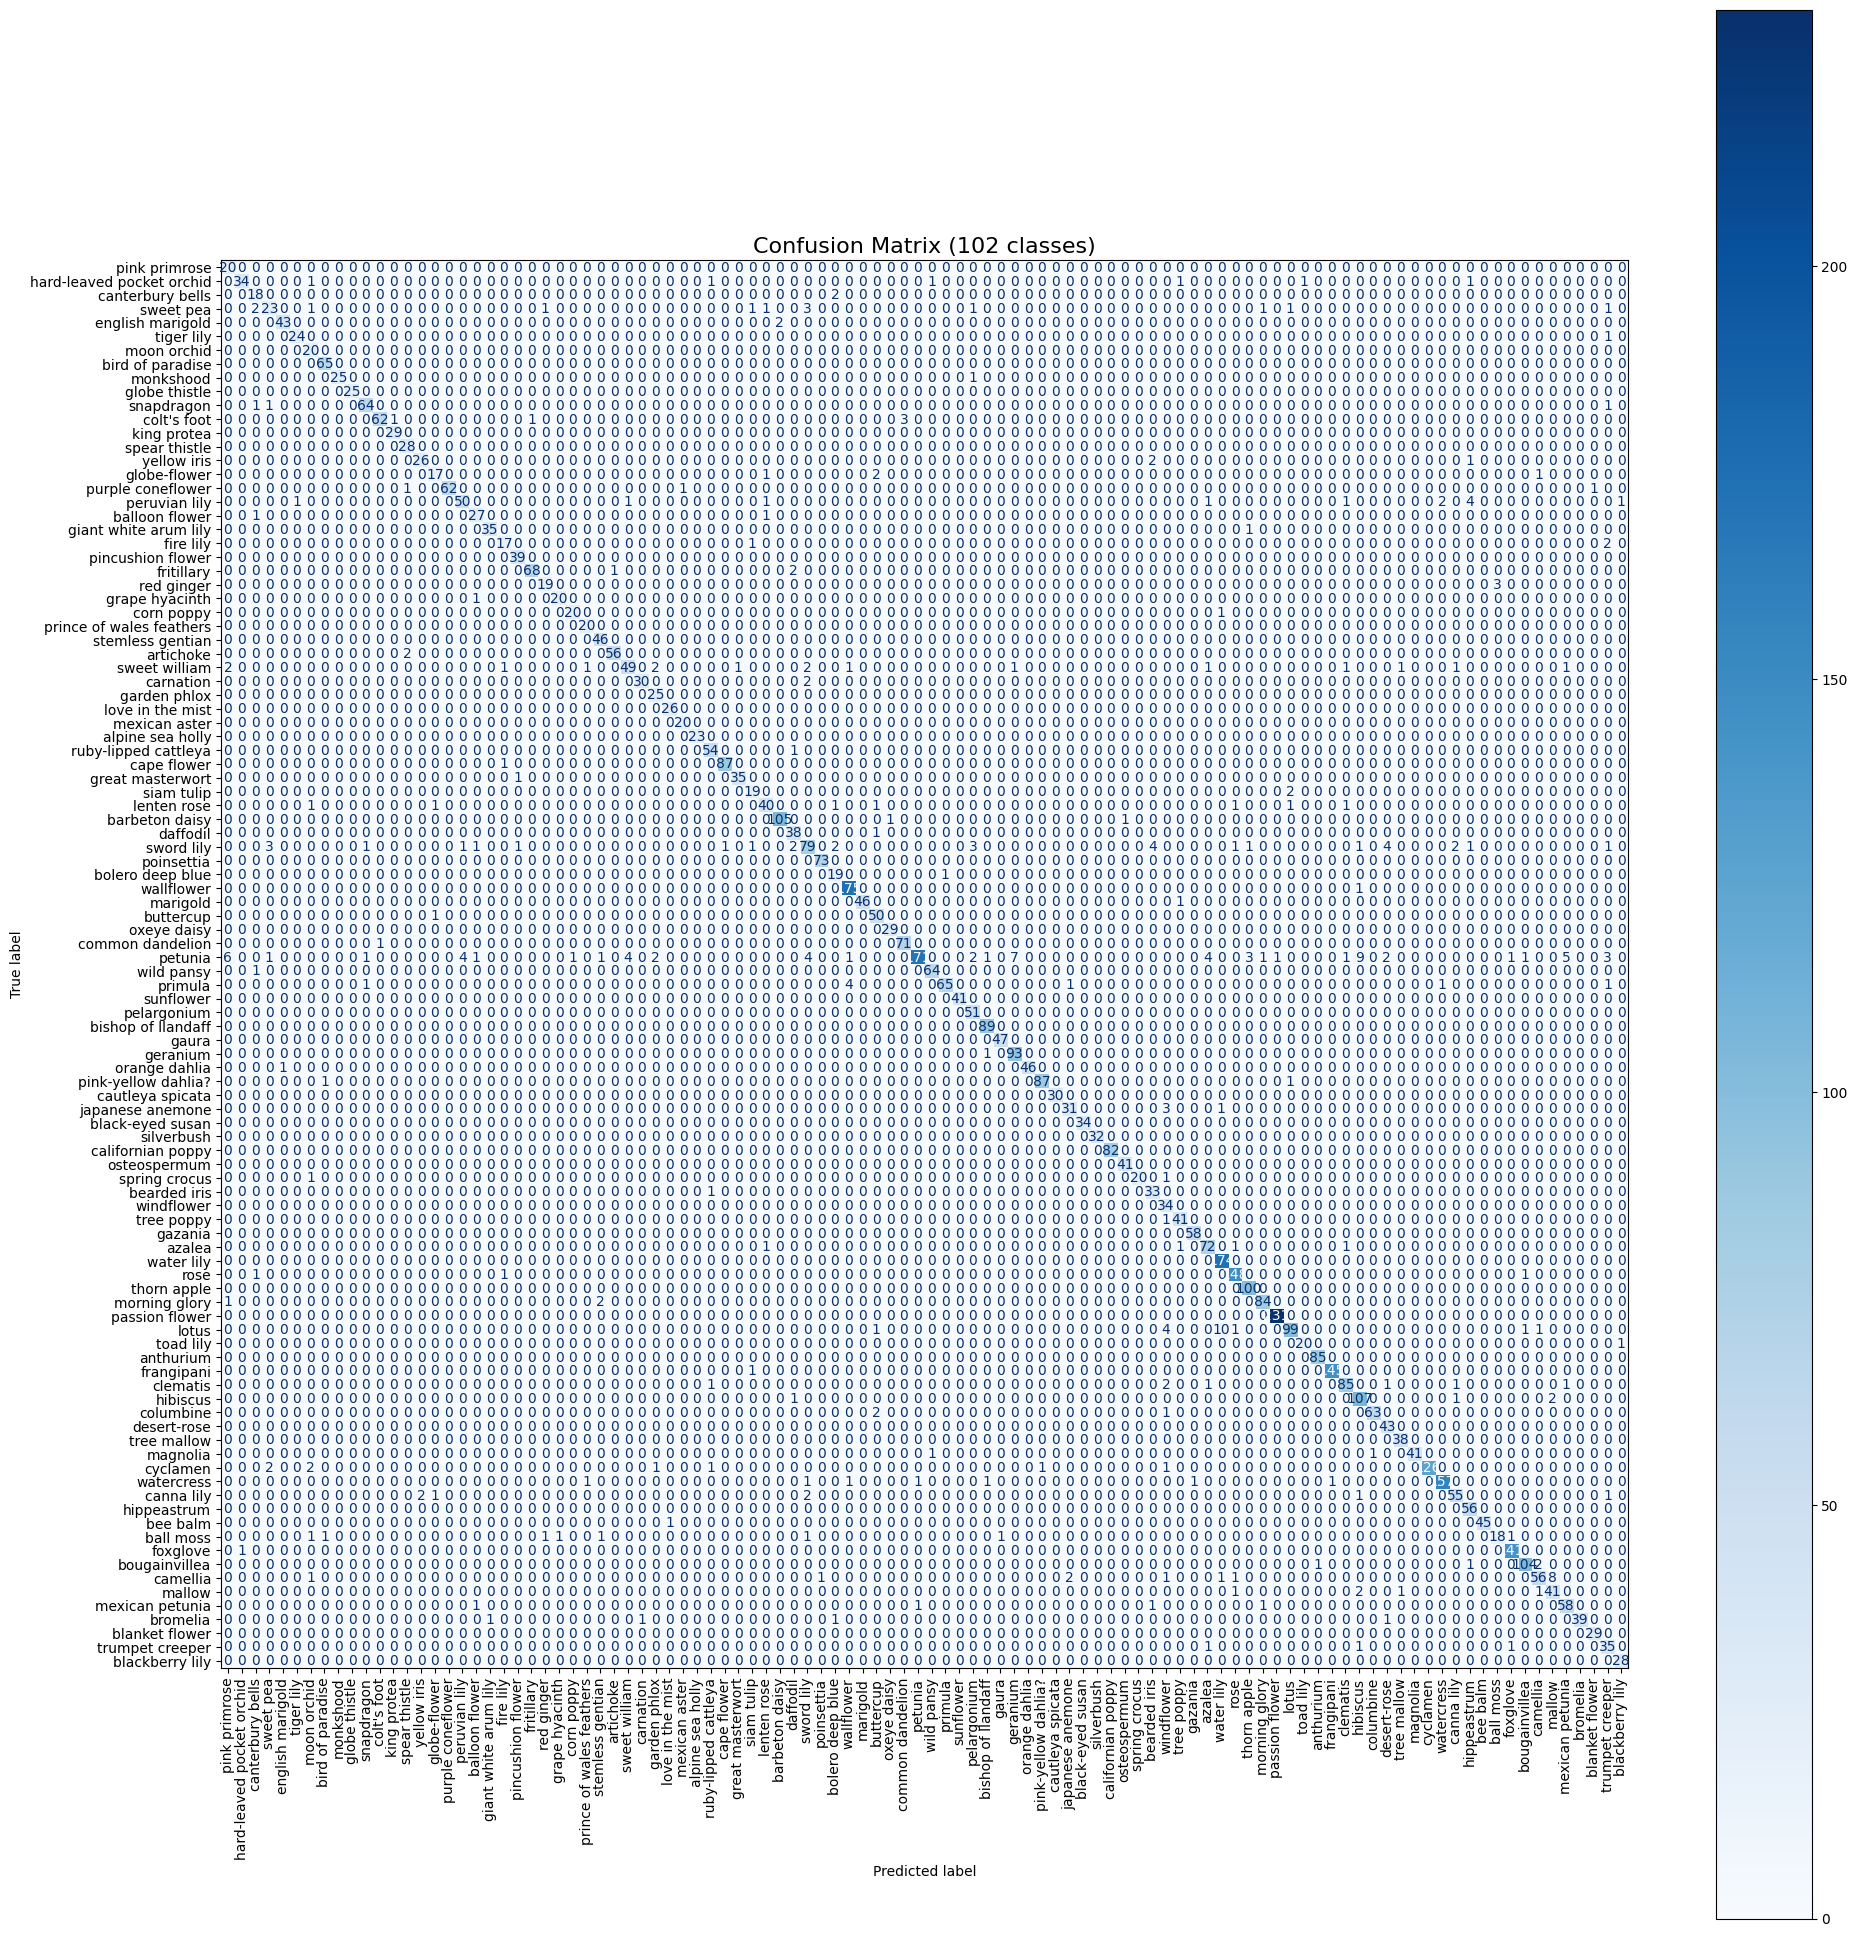